In [3]:
import sys
import pytest
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

current = Path().resolve()
sys.path.append(str(current.parents[2]))

from src.enums import *
from src.utils import *
from src.market_data import *
from src.pricer import *

MarketData.initialize()

QuantCourseBP 1c27928b12fc4d8738c1982f1861fbb4fe857821*


In [4]:
und = Stock.TEST_COMPANY
model = BSVolModel(und)
spot = model.spot
dtype = PutCallFwd.CALL
long_short = LongShort.LONG
strk = 100
exp = 1
num_mon = 100

In [5]:
contract = AsianContract(und, dtype, long_short, strk, exp, num_mon)
params = Params()
pricer_MM = AsianMomentMatchingPricer(contract, model, params)
pricer_MM.calc_fair_value()

8.055655385255223

In [6]:
params_MC = MCParams(seed = 11, num_of_path = 1000, tenor_frequency = 1)
pricer_MC = GenericMCPricer(contract, model, params_MC)
pricer_MC.calc_fair_value_with_ci()

(8.469870072121726, (7.680940726310825, 9.258799417932625))

In [7]:
vols = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
mm_prices = []
mc_prices = []

for v in vols:
    model.get_vol = lambda s, e, target_v=v: target_v

    pricer_MM = AsianMomentMatchingPricer(contract, model, params)
    mm_prices.append(pricer_MM.calc_fair_value())

    pricer_MC = GenericMCPricer(contract, model, params_MC)
    mc_val, (lower_ci, upper_ci) = pricer_MC.calc_fair_value_with_ci()
    mc_prices.append(mc_val)

difference = [abs(mc_prices[i] - mm_prices[i]) for i in range(len(vols))]


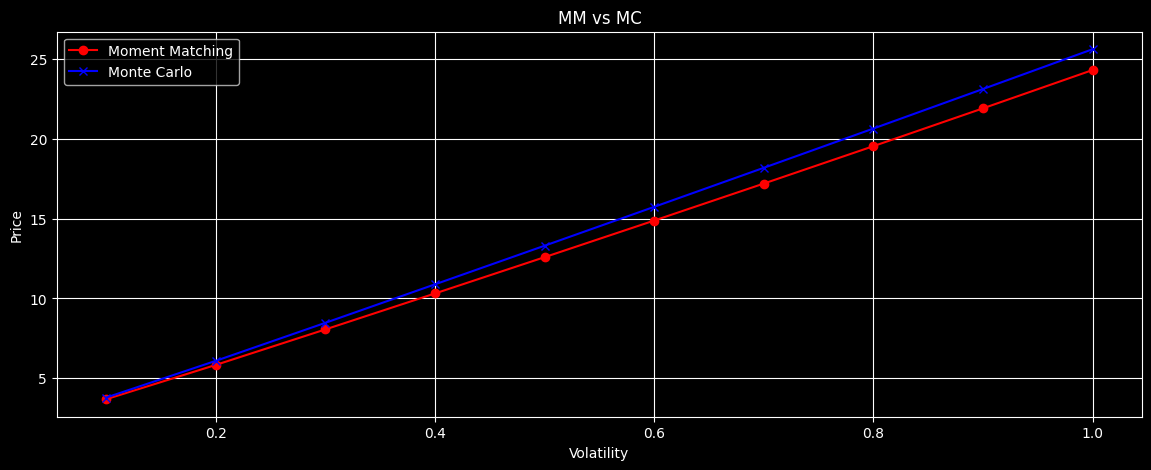

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(vols, mm_prices, 'r-o', label='Moment Matching')
plt.plot(vols, mc_prices, 'b-x', label='Monte Carlo')
plt.title('MM vs MC')
plt.xlabel('Volatility')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

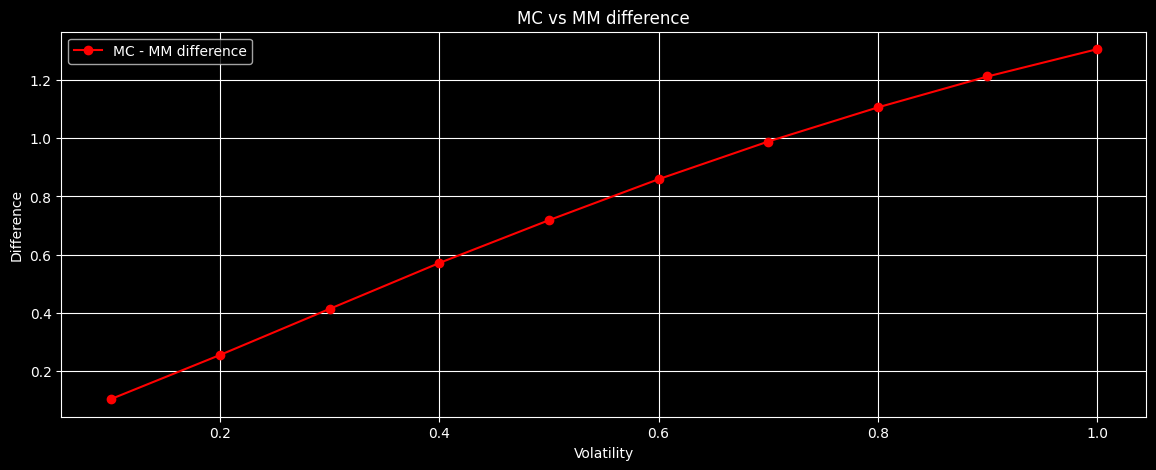

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(vols, difference, 'r-o', label='MC - MM difference')
plt.title('MC vs MM difference')
plt.xlabel('Volatility')
plt.ylabel('Difference')
plt.legend()
plt.grid(True)
plt.show()

We can see that for higher volatility the difference between the Monte-Carlo and Moment Matching methods increases.

In [15]:
num_nom = [10,100,1000,10000]
mm_values = []
mc_values = []

params_MC = MCParams(seed = 11, num_of_path = 30000, tenor_frequency = 1)

for i in num_nom:
    contract = AsianContract(und, dtype, long_short, strk, exp, i)
    params = Params()

    pricer_MM = AsianMomentMatchingPricer(contract, model, params)
    pricer_MM.calc_fair_value()
    mm_values.append(pricer_MM.calc_fair_value())

    pricer_MC = GenericMCPricer(contract, model, params_MC)
    pricer_MC.calc_fair_value_with_ci()
    mc_values.append(pricer_MC.calc_fair_value_with_ci())

print(mm_values)
print(mc_values)

[25.810469588311676, 24.315801332029885, 24.165675345307264, 24.15065601797238]
[(25.279706291205667, (24.682883345776634, 25.8765292366347)), (23.356198853854046, (22.757143957876696, 23.955253749831392)), (23.453853397761137, (22.83865456798291, 24.069052227539366)), (23.049388087005102, (22.46072287085126, 23.638053303158944))]


In [17]:
for i in range(len(num_nom)):
    pmm = mm_values[i]
    pmc, (low_ci, high_ci) = mc_values[i]

    is_appropriate = low_ci <= pmm <= high_ci

    sd_mc = (high_ci - pmc) / 1.96
    z_score = (pmm - pmc) / sd_mc

    print(f"n={num_nom[i]} | Z-score: {z_score:.4f} | Appropriate: {is_appropriate}")

n=10 | Z-score: 1.7431 | Appropriate: True
n=100 | Z-score: 3.1396 | Appropriate: False
n=1000 | Z-score: 2.2678 | Appropriate: False
n=10000 | Z-score: 3.6667 | Appropriate: False


Because of the CLT theorem if we make n larger or goes to infinity the A(t) average becomes normally distributed but we choose U for the approximation to be lognormally distributed. This creates an error. As we can see the MM calculated values differ from the MC ones.